### OC22 LMDB Dataset Tutorial

This notebook provides an overview of how to create LMDB datasets to be used with the OCP repo. This tutorial is intended for those who wish to use OCP to train on their own datasets. Those interested in just using OCP data need not worry about these steps as they've been automated as part of the download script: https://github.com/Open-Catalyst-Project/ocp/blob/master/scripts/download_data.py.

In [1]:
import sys
sys.path.append(r"D:\Train_thử\fairchem-tio2-s2ef")

from ocpmodels.preprocessing import AtomsToGraphs
from ocpmodels.datasets import SinglePointLmdbDataset, TrajectoryLmdbDataset, OC22LmdbDataset, LmdbDataset
import ase.io
from ase.build import bulk
from ase.build import fcc100, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.optimize import BFGS
import matplotlib.pyplot as plt
import lmdb
import pickle
from tqdm import tqdm
import torch
import os

### Structure to Energy and Forces (S2EF) LMDBs

S2EF LMDBs utilize the TrajectoryLmdb dataset. This dataset expects a directory of LMDB files. In addition to the attributes defined by AtomsToGraph, the following attributes must be added for the S2EF task:

In [2]:
# dataset = TrajectoryLmdbDataset({"src": "s2ef/"})
# dataset = OC22LmdbDataset({"src": r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\s2ef_total_train_val_test_lmdbs\data\oc22\s2ef-total\val_ood\data.0000.lmdb"})
dataset = LmdbDataset({"src": r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\tio2_filtered\train"})

len(dataset)


1197

#### Advanced usage

TrajectoryLmdbDataset supports multiple LMDB files because the need to highly parallelize the dataset construction process. With OCP's largest split containing 135M+ frames, the need to parallelize the LMDB generation process for these was necessary. If you find yourself needing to deal with very large datasets we recommend parallelizing this process.

### Interacting with the LMDBs

Below we demonstrate how to interact with an LMDB to extract particular information.

In [3]:
data = dataset[1000]
data

Data(y=-845.34728644, pos=[97, 3], cell=[1, 3, 3], atomic_numbers=[97], natoms=97, force=[97, 3], fixed=[97], tags=[97], nads=3, sid=12032, fid=396, id='19_20', oc22=1)

### Check specific sid in dataset

In [4]:
# Filter for a specific sid in the dataset
target_sid = 23315
data = None
for i in range(len(dataset)):
    try:
        if dataset[i].sid == target_sid:
            data = dataset[i]
            print(f"Data for sid {target_sid} found at index {i}")
            break
    except (TypeError, AttributeError):
        # Skip corrupted or null entries
        continue
if data is None:
    print(f"Sid {target_sid} not found")
else:
    data  # Display the data

Data for sid 23315 found at index 4


In [5]:
data

Data(y=-802.89450021, pos=[92, 3], cell=[1, 3, 3], atomic_numbers=[92], natoms=92, force=[92, 3], fixed=[92], tags=[92], nads=1, sid=23315, fid=106, id='0_4', oc22=1)

In [6]:
from ase.data import chemical_symbols

# Assuming 'data' is your dataset[0]
atom_list = [chemical_symbols[int(z)] for z in data.atomic_numbers]

print(f"Elements in this system: {atom_list}")

# To see which atoms are the 'adsorbate' (molecule) vs 'surface'
for i, symbol in enumerate(atom_list):
    tag = data.tags[i].item()
    role = "Subsurface" if tag == 0 else "Surface" if tag == 1 else "Adsorbate"
    print(f"Atom {i}: {symbol} ({role}) at {data.pos[i].tolist()}")

Elements in this system: ['Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'Ti', 'C', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
Atom 0: Ti (Subsurface) at [2.7126872539520264, 6.976807117462158, 12.356963157653809]
Atom 1: Ti (Subsurface) at [8.723925590515137, 2.2865407466888428, 12.704602241516113]
Atom 2: Ti (Subsurface) at [5.688468933105469, 0.1332346647977829, 13.027460098266602]
Atom 3: Ti (Subsurface) at [-0.3216237425804138, 4.726400375366211, 12.79949951171875]
Atom 4: Ti (Subsurface) at [2.816664695739746, 0.34745752811431885, 12.408113479614258]
Atom 5: Ti (Subsurface) at [6.885254383087158,

### Visualization

In [7]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [8]:
from ase import Atoms
from ase.visualize import view
import torch

# 1. Extract the information from your Data object
# We reshape the cell from [1, 3, 3] to [3, 3]
positions = data.pos.numpy()
numbers = data.atomic_numbers.numpy().astype(int)
cell = data.cell.view(3, 3).numpy()

# 2. Create the ASE Atoms object
structure = Atoms(
    numbers=numbers,
    positions=positions,
    cell=cell,
    pbc=True # Periodic Boundary Conditions are standard for OCP
)

# 3. Open the visualizer
view(structure)

# Optional: Save it as a 3D file for VESTA or Ovito
structure.write("system_2090899_frame_206.xyz")

In [9]:
energies = torch.tensor([data.y for data in dataset])
len(energies)

1197

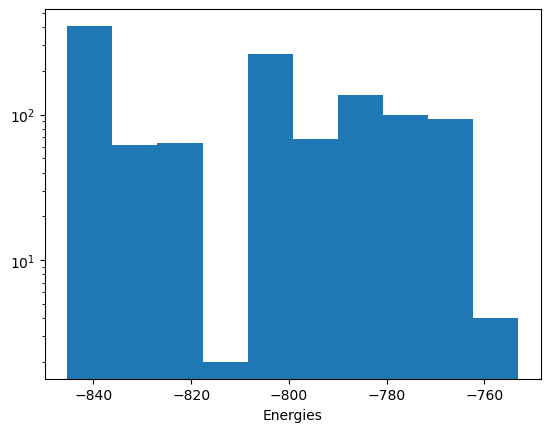

In [10]:
plt.hist(energies, bins = 10)
plt.yscale("log")
plt.xlabel("Energies")
plt.show()

### 3D Visualization

In [13]:
import ase.io
from ase import Atoms
import torch

# 1. Access the specific data object (e.g., sid 2090899, fid 206)
data = dataset[0] 

# 2. Convert to ASE Atoms object
# Reshape the cell to [3, 3] as required by ASE
atoms = Atoms(
    numbers=data.atomic_numbers.numpy().astype(int),
    positions=data.pos.numpy(),
    cell=data.cell.view(3, 3).numpy(),
    pbc=True
)

# 3. Attach metadata (This makes it "Extended")
# We store energy and forces so other models or Ovito can read them
atoms.info["energy"] = data.y.item() if isinstance(data.y, torch.Tensor) else data.y
atoms.arrays["forces"] = data.force.numpy()
atoms.info["sid"] = str(data.sid)
atoms.info["fid"] = str(data.fid)

# 4. Save as ExtXYZ
ase.io.write("system_data.extxyz", atoms, format="extxyz")

In [25]:
from ase.visualize import view
import ase.io

# 1. Đọc dữ liệu từ file ExtXYZ bạn đã tạo
atoms = ase.io.read("system_data.extxyz")

# 2. Hiển thị bằng viewer 'x3d' (nó sẽ hiện ra một cửa sổ tương tác 3D)
view(atoms, viewer='x3d')